In [1]:
%load_ext autoreload
%autoreload 2

from src import GraspAnalysisResults, GraspRegion, InitializationAngle
from src.utils import GraspAnalysisUtils
from pathlib import Path
import numpy as np

In [2]:
# Find folder containing CSV files for analysis
data_file = GraspAnalysisUtils.select_file()

Selected file: C:/Users/rjs15/Documents/FY26/Grasping/Grasp_Strength_Python/data/robotiq_intialization/RobotIQ_70SFMA_33Cycles_DeterminePositionMaxGraspStrength.csv


In [3]:
# Get initialization variables
init_variables = InitializationAngle
init_variables = GraspAnalysisUtils.get_initialization_parameters(init_variables)

User has chosen a starting angle of -25.0 degrees

User has chosen an angle increment of 5.0 degrees

User has specified 3.0 per angle increment


In [4]:
# Plot Dialog Selection
chosen_plots = GraspAnalysisUtils.select_desired_plots()
print(f"User wants to create: {chosen_plots}")

User wants to create: []


In [5]:
# Assignment of variables
SAMPLE_SIZE = 200
OFFSET = 2000
MIN_FORCE_THRESHOLD = 10

Filename: RobotIQ_70SFMA_33Cycles_DeterminePositionMaxGraspStrength.csv
Optimal angle: 5.0 degrees
Force at optimal angle: 179 N
Number of grasps analyzed: 33


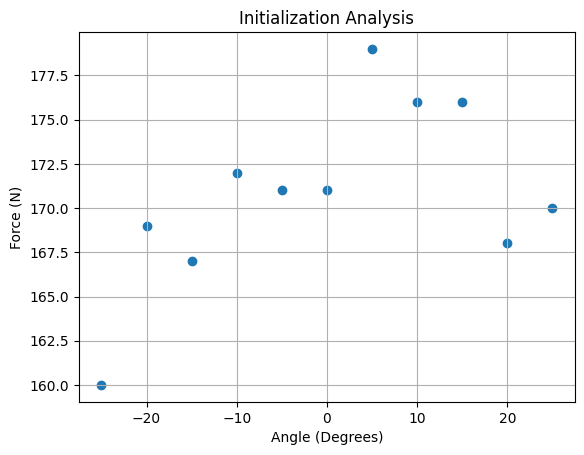

In [17]:
result = GraspAnalysisResults
full_path = Path(data_file)

result.filename = full_path.name

force_data = GraspAnalysisUtils.load_and_preprocess_data(data_file)

grasps = GraspAnalysisUtils.detect_grasp_regions(force_data, SAMPLE_SIZE, MIN_FORCE_THRESHOLD)
result.number_of_grasps = len(grasps)

if result.number_of_grasps == 0:
    Warning(f"No grasps detected in file: {result.filename}")

result.rolling_avg = []
result.rolling_std = []
result.rolling_median = []

avg_forces = []
for grasp in grasps:
    grasp = GraspAnalysisUtils.calculate_grasp_force(force_data[grasp.start_idx:grasp.end_idx], grasp, OFFSET)

    avg_forces.append(grasp.avg_force)
    result.rolling_avg.append(np.mean(avg_forces))
    result.rolling_std.append(np.std(avg_forces))
    result.rolling_median.append(np.median(avg_forces))

init_variables = GraspAnalysisUtils.analyze_initialization_angles(avg_forces, init_variables, result.number_of_grasps)

GraspAnalysisUtils.report_initialization_results(result, init_variables)